In [36]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



Filter for US Data Analyst Roles
--------

Text(0, 0.5, '')

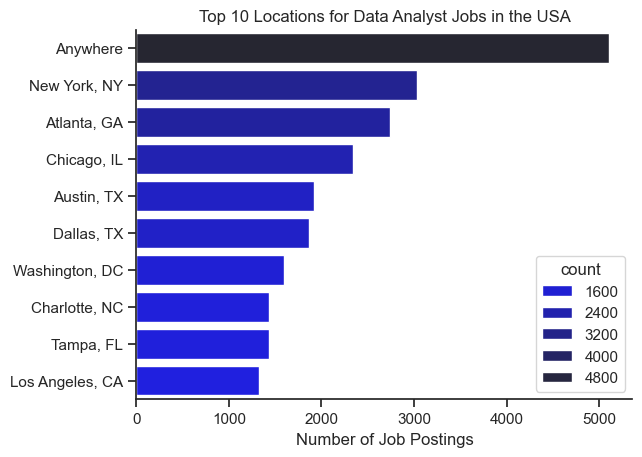

In [37]:
df_DA_USA= df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')]
df_DA_USA_locations = df_DA_USA['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style="ticks")
sns.barplot(data=df_DA_USA_locations, x='count', y='job_location', hue='count', palette='dark:blue_r')
sns.despine()
plt.title('Top 10 Locations for Data Analyst Jobs in the USA')
plt.xlabel('Number of Job Postings')
plt.ylabel('')

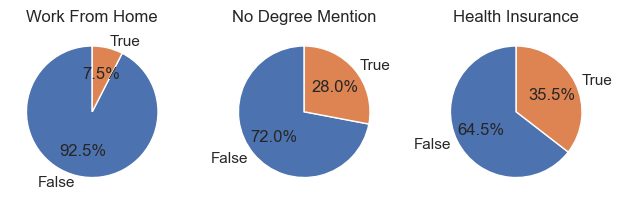

In [38]:
df[['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']]

fig, ax = plt.subplots(1,3)
dict_columns = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'No Degree Mention',
    'job_health_insurance': 'Health Insurance'
}

for i, (col, title) in enumerate(dict_columns.items()):
    df_DA_USA[col].value_counts().plot(kind='pie', ax=ax[i], startangle=90, autopct='%1.1f%%')
    ax[i].set_title(title)

plt.tight_layout()
plt.show()


In [39]:
df_DA_USA['job_no_degree_mention'].value_counts()

job_no_degree_mention
False    48840
True     18976
Name: count, dtype: int64

Text(0, 0.5, '')

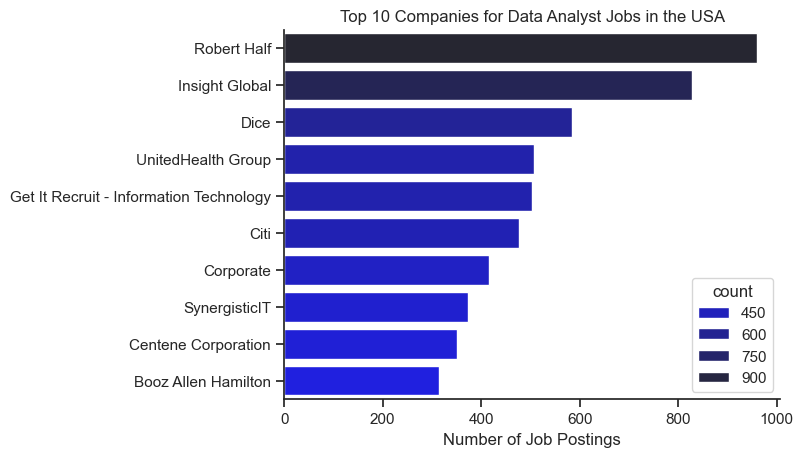

In [40]:
df_DA_USA_companies = df_DA_USA['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style="ticks")
sns.barplot(data=df_DA_USA_companies, x='count', y='company_name', hue='count', palette='dark:blue_r')
sns.despine()
plt.title('Top 10 Companies for Data Analyst Jobs in the USA')
plt.xlabel('Number of Job Postings')
plt.ylabel('')

In [41]:
df_DA_USA_companies

,count
company_name,
Robert Half,959
Insight Global,827
Dice,584
UnitedHealth Group,507
Get It Recruit - Information Technology,503
Citi,477
Corporate,416
SynergisticIT,374
Centene Corporation,350
